## Detrending the seasonality from the data

Detrend the data, then normalise the residual for GP.

In [1]:
import matplotlib.pyplot as plt
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
from pandas.plotting import register_matplotlib_converters

from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.seasonal import DecomposeResult

register_matplotlib_converters()
sns.set_style("darkgrid")

In [2]:
plt.rc("figure", figsize=(16, 12))
plt.rc("font", size=13)

In [4]:
# Data
z500 = xr.open_mfdataset('STGP-weather-forecasting/data/5.625deg/geopotential_500/*.nc', combine='by_coords')
data = z500.sel(time=slice('2017.12', '2017.12',6))

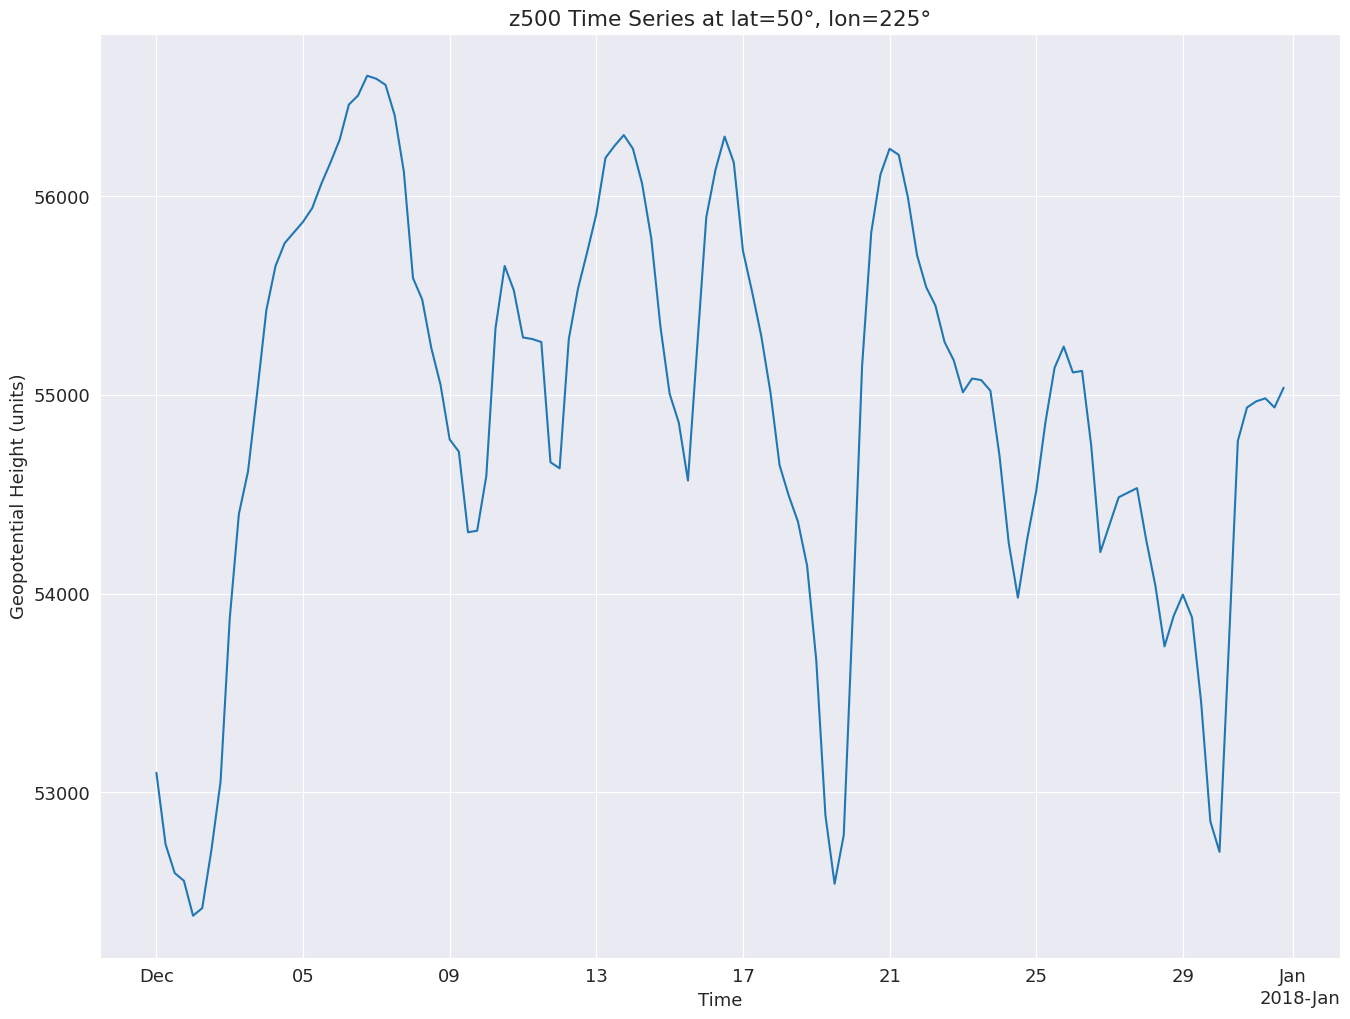

In [5]:
point_worst = data['z'].sel(lat=50, lon=225, method='nearest')
point_worst.plot.line(x='time')
plt.xlabel('Time')
plt.ylabel('Geopotential Height (units)')
plt.title('z500 Time Series at lat=50°, lon=225°')
plt.show()

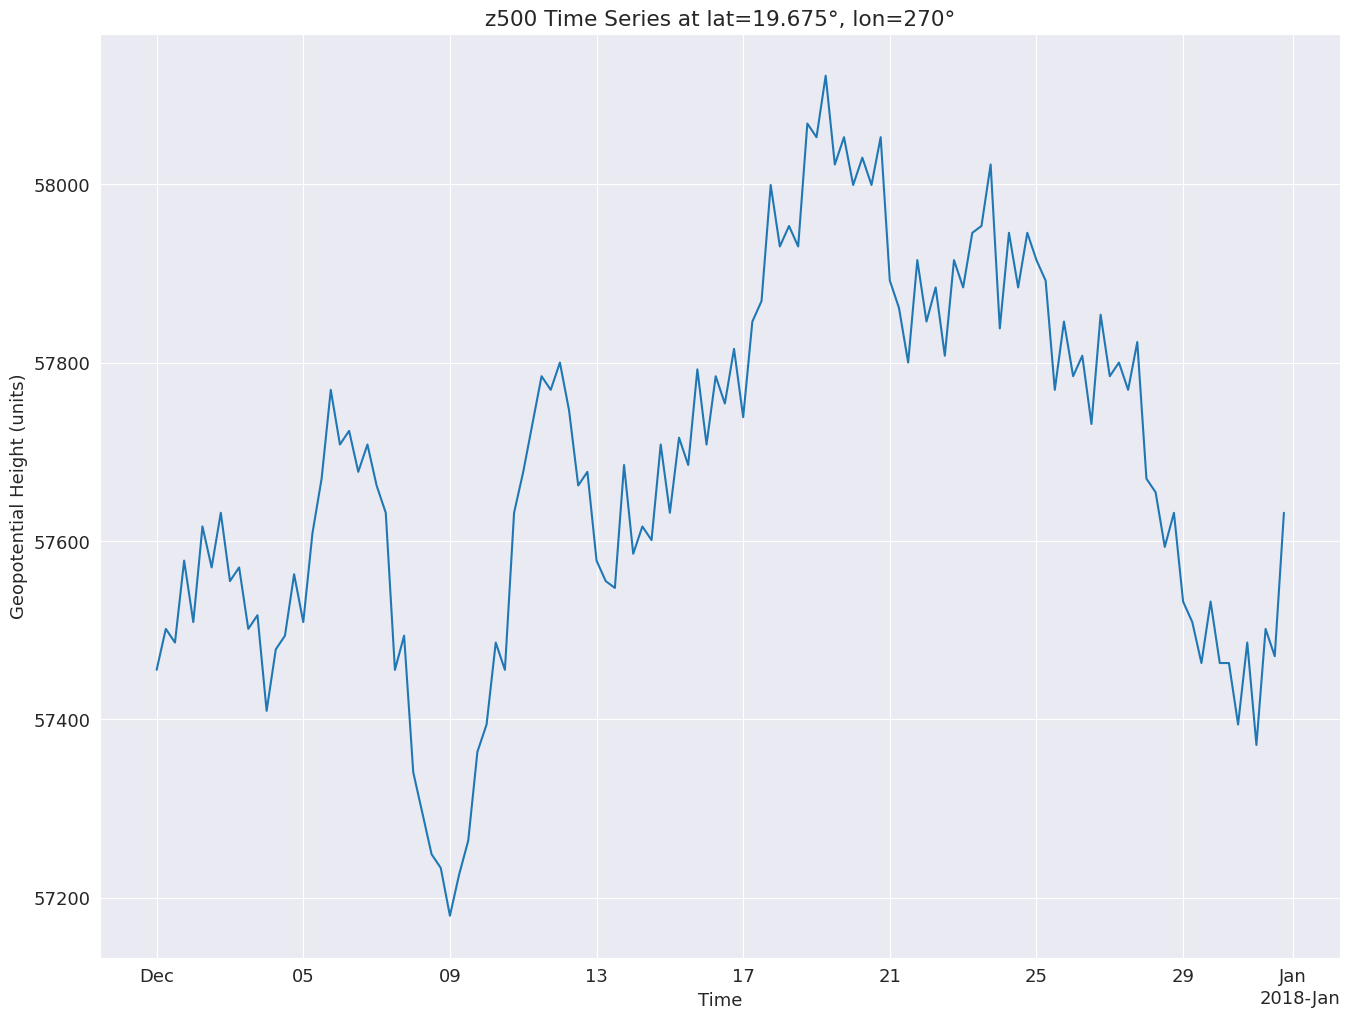

In [6]:
point_best = data['z'].sel(lat=19.6, lon=270, method='nearest')
point_best.plot.line(x='time')
plt.xlabel('Time')
plt.ylabel('Geopotential Height (units)')
plt.title('z500 Time Series at lat=19.675°, lon=270°')
plt.show()

Detrend the data at (50,225) into a trend + daily + weekly seasonal component and a residual component.

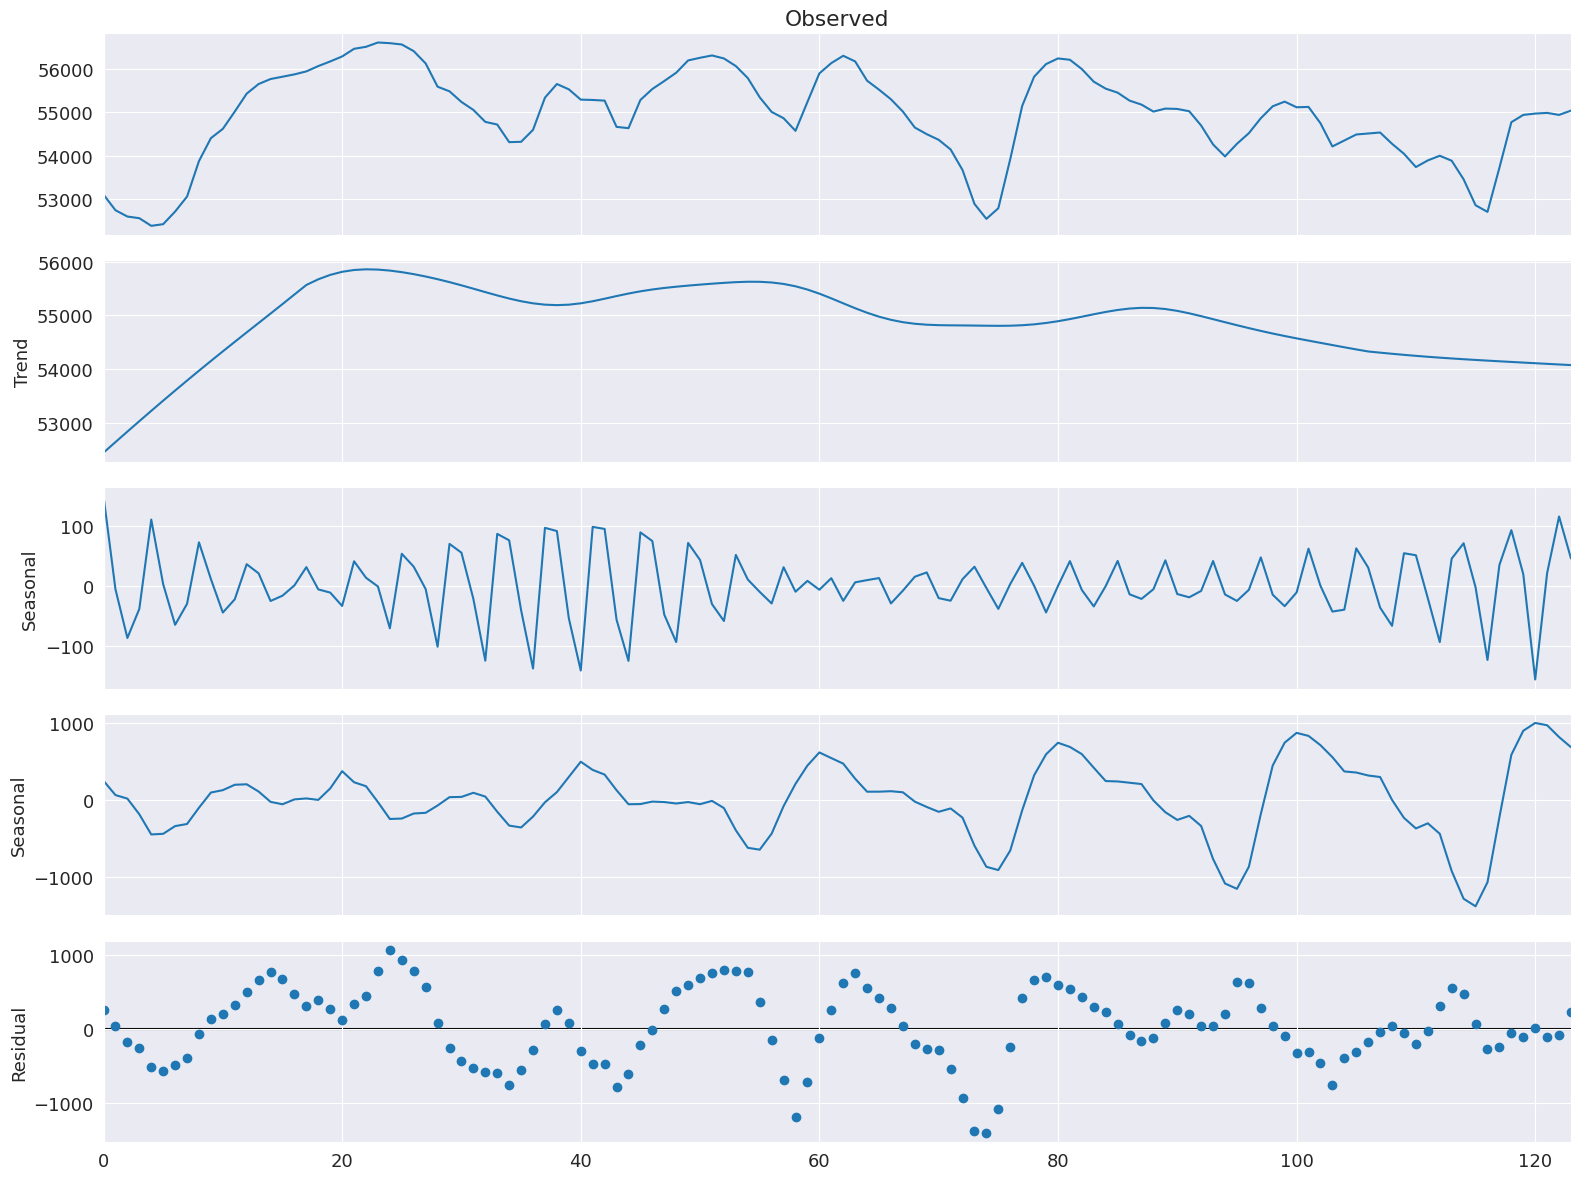

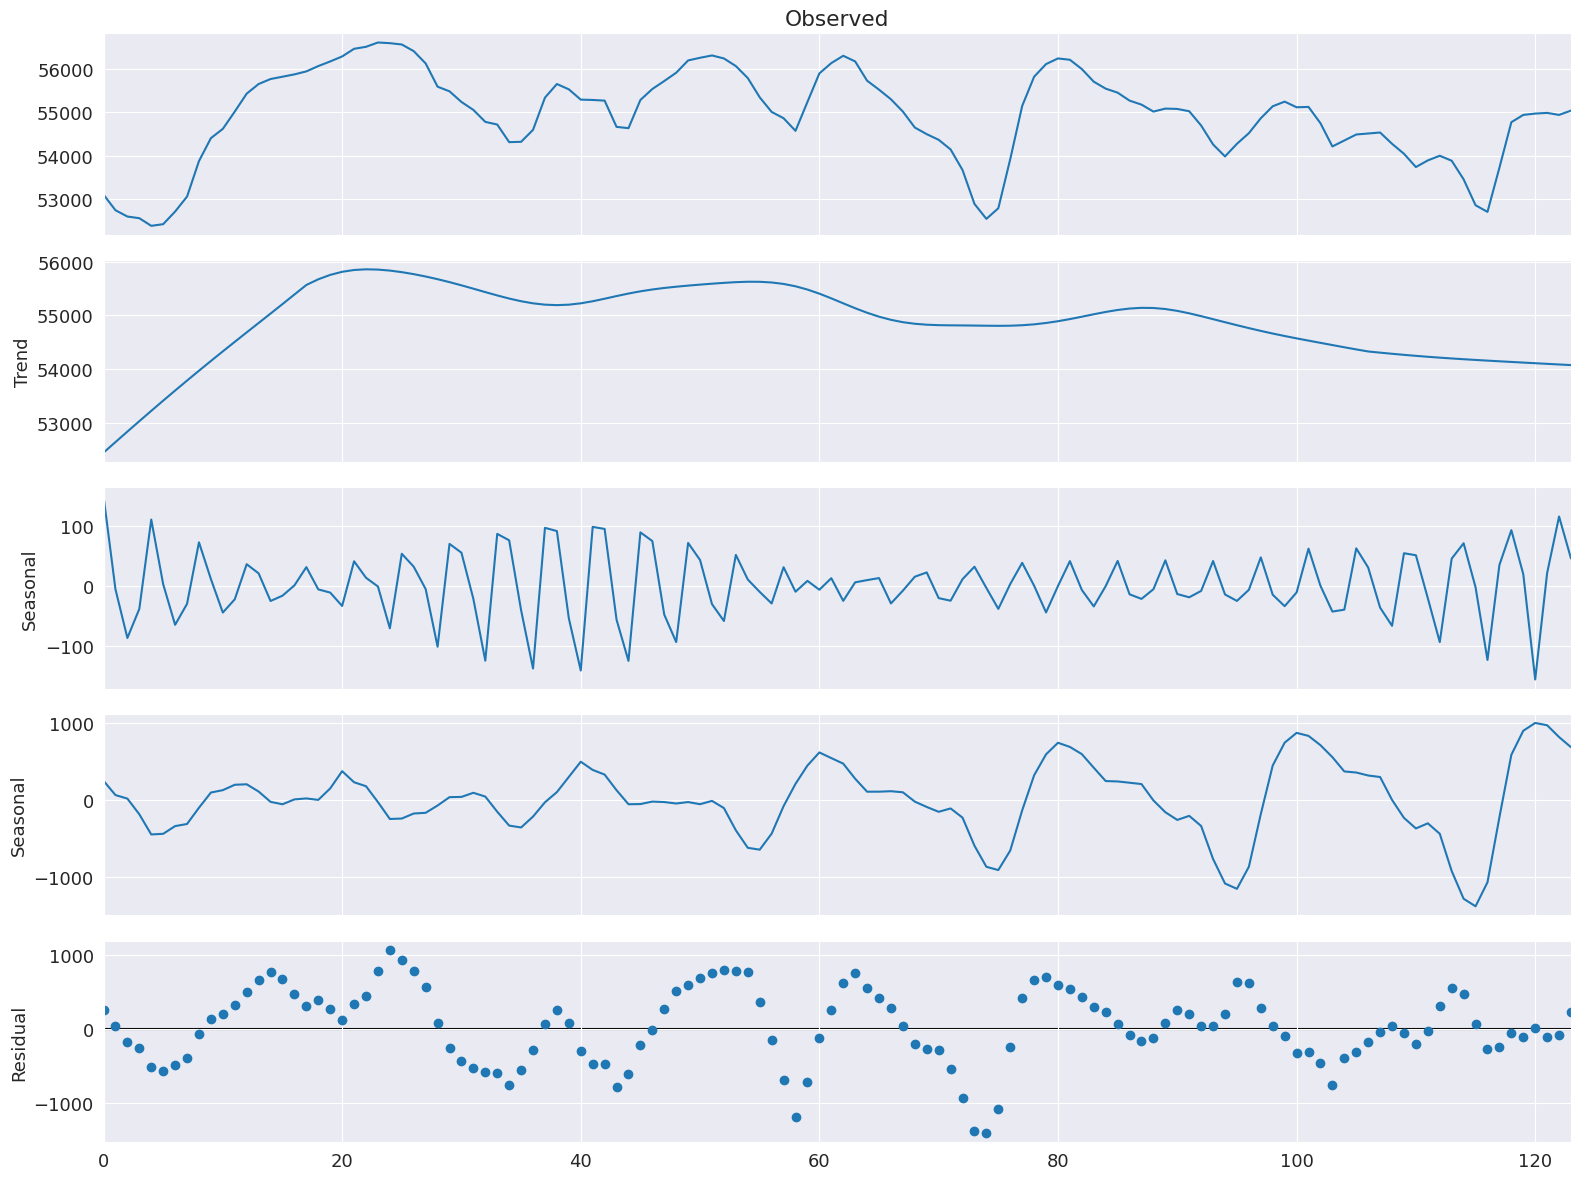

In [9]:
detrend_point_worst = MSTL(point_worst, periods=[4, 4 * 5])
residual_point_worst = detrend_point_worst.fit()
residual_point_worst.plot()

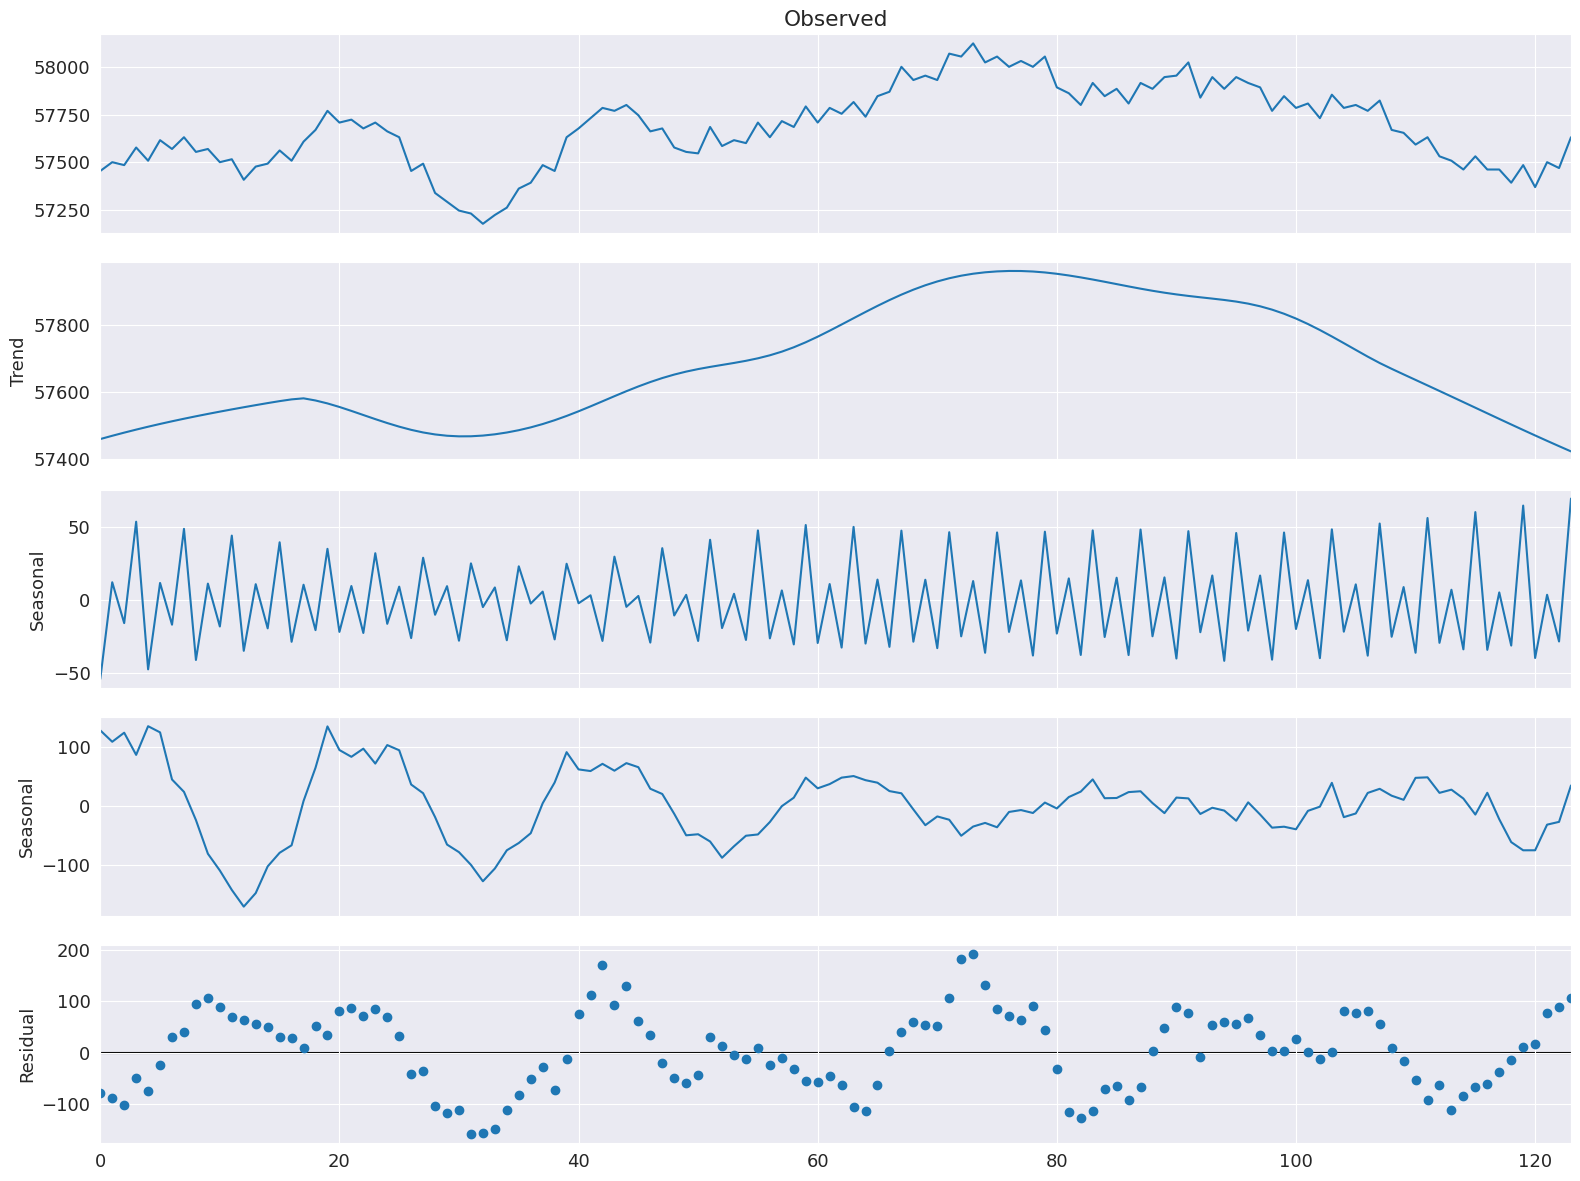

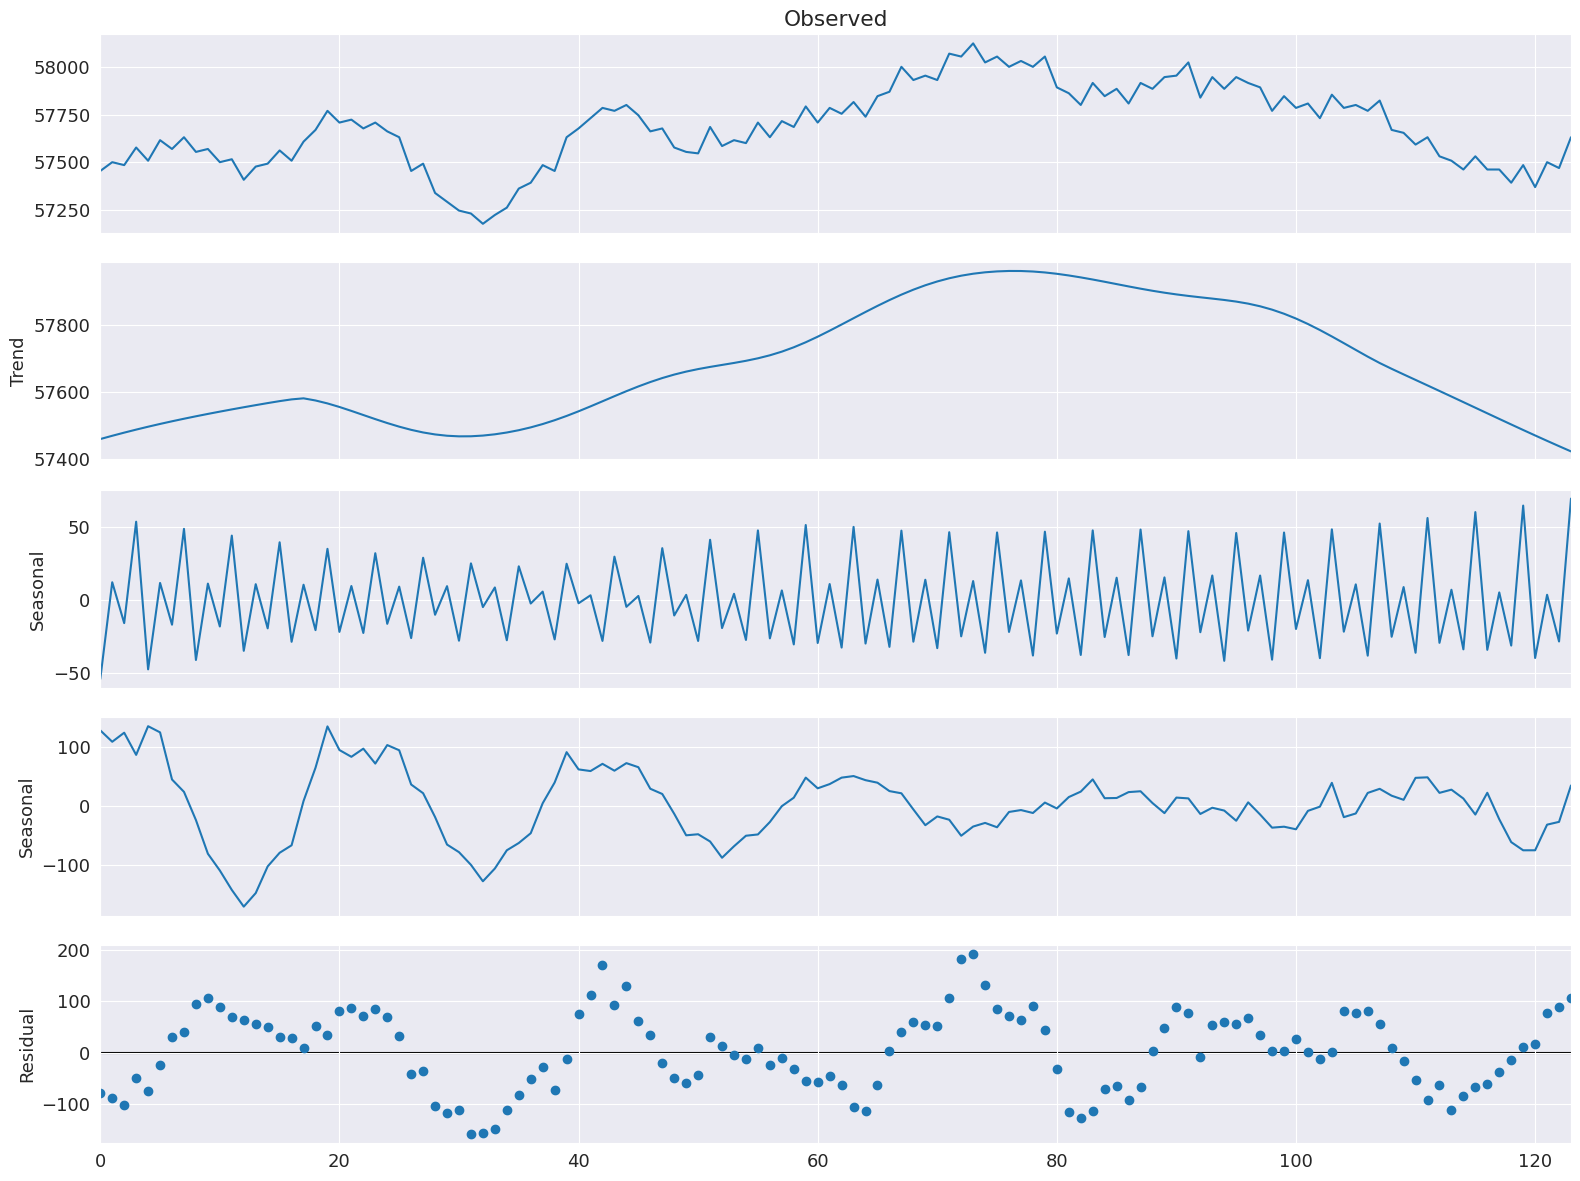

In [10]:
detrend_point_best = MSTL(point_best, periods=[4, 4 * 5])
residual_point_best = detrend_point_best.fit()
residual_point_best.plot()

In [11]:
residual_point_best.resid.shape

(124,)

<xarray.DataArray 'z' (lat: 32, lon: 64, time: 124)> Size: 2MB
array([[[ 294.75552461,  212.95326557,  130.83127564, ...,
           28.17022629,    9.52913053,    7.10985714],
        [ 303.6345513 ,  223.54889812,  141.18769002, ...,
           22.75939537,   -0.69186023,    3.66367069],
        [ 314.76489491,  235.50021089,  154.98395188, ...,
           19.8585332 ,   -2.1011175 ,   -1.16483412],
        ...,
        [ 267.23009633,  182.88651482,   98.82174146, ...,
           42.41005481,   36.75159689,   31.0667789 ],
        [ 273.04220686,  189.53873672,  111.28295919, ...,
           37.57492865,   28.04020605,   20.90089101],
        [ 283.70444365,  202.26472865,  119.75986395, ...,
           33.49935401,   19.03809428,   12.20293159]],

       [[ 140.52362825,  112.00332488,   53.3189038 , ...,
         -115.44771287, -262.43286173, -363.7644163 ],
        [ 158.29774981,  131.67725878,   72.75728269, ...,
         -136.85673642, -255.44199043, -337.92307289],
        [ 

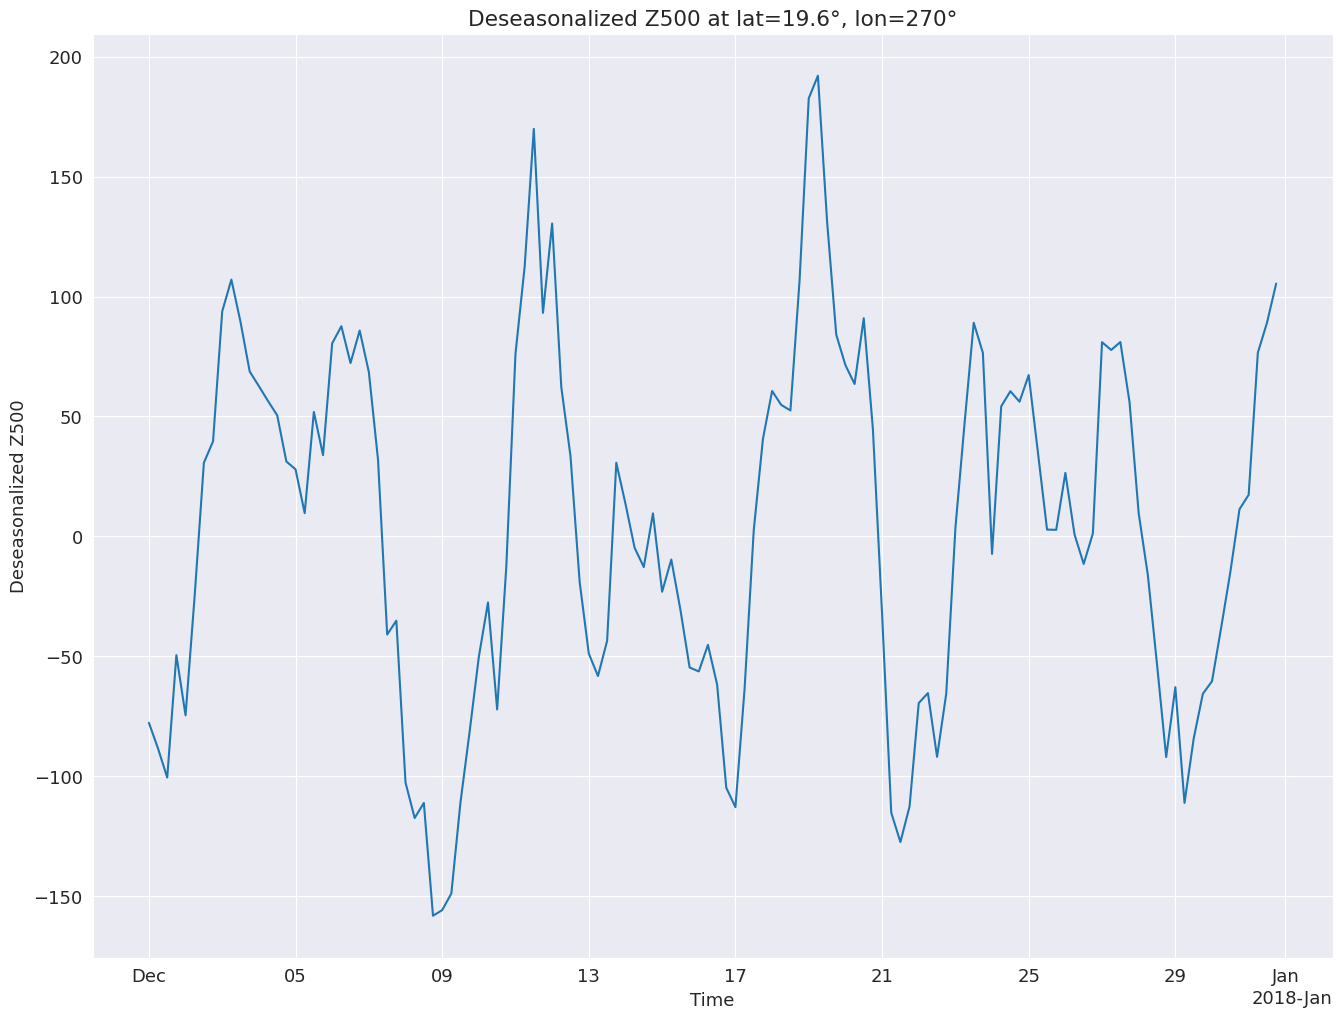

In [12]:
def mstl_detrend(ts, periods):
    """
    Apply MSTL decomposition to a 1D numpy array and return the residuals.
    
    Parameters
    ----------
    ts : array_like
        Time series data.
    period : array_like
        Enter multiple seasonal period you suspect in an array form. For 
        instance, if we suspect daily and weekly periodicity, we enter 
        period = [24, 24*5]
    
    Returns
    -------
    detrended_ts : numpy array
        The residual time series after removing the seasonal component.
    """
    detrend = MSTL(ts, periods=periods).fit()
    return detrend.resid

periods = [4, 4*5]

residuals = xr.apply_ufunc(
    mstl_detrend,       
    data['z'].load(),                 
    input_core_dims=[['time']],  
    output_core_dims=[['time']],
    kwargs={'periods': periods},   
    vectorize=True,    
)

# residuals for GP regression.
print(residuals)

# Plot an example time series from a specific grid point
example_ts = residuals.sel(lat=19.6, lon=270, method='nearest')
example_ts.plot.line()
plt.xlabel('Time')
plt.ylabel('Deseasonalized Z500')
plt.title('Deseasonalized Z500 at lat=19.6°, lon=270°')
plt.show()